<a href="https://colab.research.google.com/github/utkarsh6174/ML/blob/main/30_function_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#making the distribution normal .

In [ ]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [ ]:
df  = pd.read_csv('/content/train (1) titanic.csv',usecols=['Age','Fare','Survived'])


In [ ]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [ ]:
df['Age'].fillna(df['Age'].mean(),inplace = True)

/tmp/ipykernel_587/1652017284.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace = True)


In [ ]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [ ]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [ ]:
X_train, X_test , y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 24)


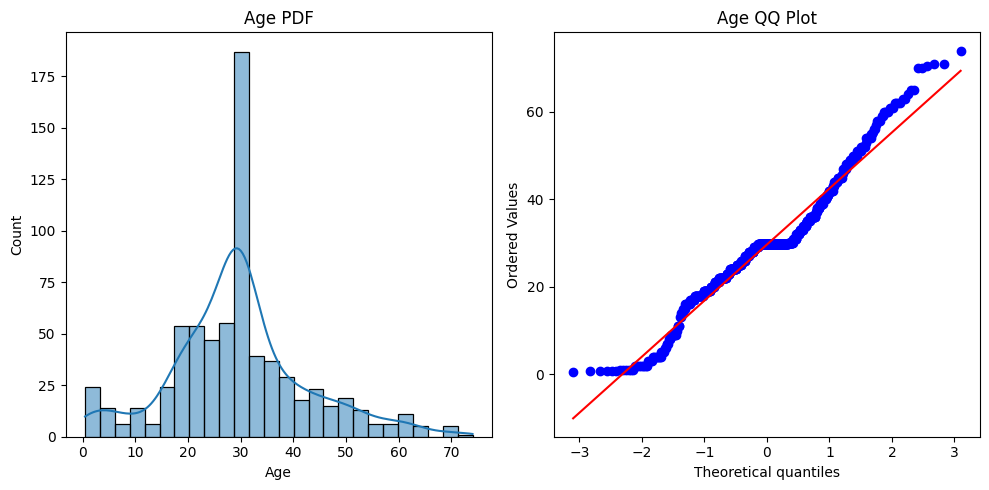

In [ ]:
plt.figure(figsize=(10,5))

# PDF Plot
plt.subplot(121)
#This is shorthand for:
#plt.subplot(1,2,1)
#Meaning: 1 row #2 columns #1st plot position
sns.histplot(X_train['Age'], kde=True)
plt.title('Age PDF')

# QQ Plot
plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.tight_layout()
plt.show()


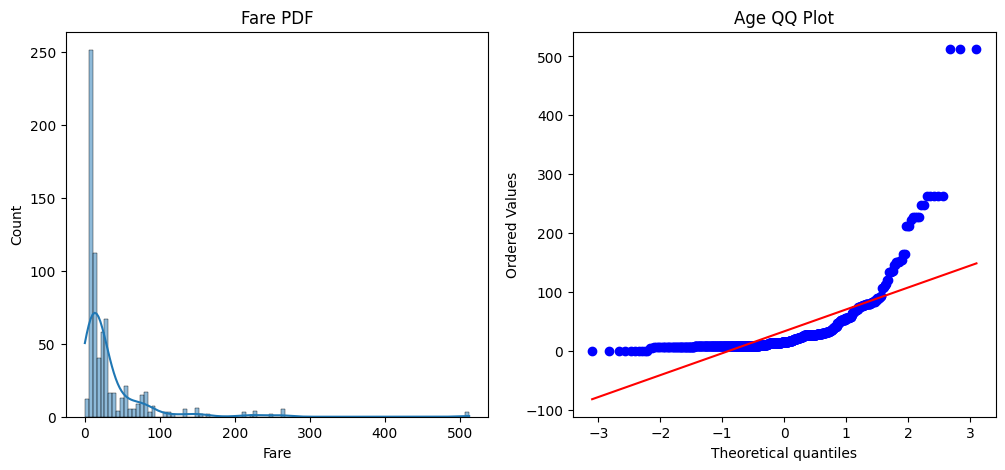

In [ ]:
plt.figure(figsize =(12,5))
plt.subplot(121)
sns.histplot(X_train['Fare'],kde = True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'],dist = 'norm',plot = plt)
plt.title('Age QQ Plot')
plt.show()

In fare we can see that right skewed so log transformation

In [ ]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()


In [ ]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test)
y_pred2 = clf2.predict(X_test)

print("Accuracy LR ",accuracy_score(y_test,y_pred))
print("Accuracy DT ",accuracy_score(y_test,y_pred2))

Accuracy LR  0.7206703910614525
Accuracy DT  0.659217877094972


now apply log transformation

In [ ]:
trf = FunctionTransformer(func = np.log1p)

In [ ]:
X_train_trans = trf.fit_transform(X_train)
X_test_trans = trf.transform(X_test)

In [ ]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_trans,y_train)
clf2.fit(X_train_trans , y_train)

y_pred = clf.Zpredict(X_test_trans)
y_pred2 = clf2.predict(X_test_trans)

print("Accuracy LR ",accuracy_score(y_test,y_pred))
print("Accuracy DT ",accuracy_score(y_test,y_pred2))

Accuracy LR  0.7430167597765364
Accuracy DT  0.6927374301675978


In [ ]:
X_trans = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR ",np.mean(cross_val_score(clf,X_trans,y, scoring = 'accuracy',cv=10)))
print("DT ",np.mean(cross_val_score(clf2,X_trans,y,scoring = 'accuracy',cv = 10)))



LR  0.678027465667915
DT  0.6588389513108615


before transform after transform

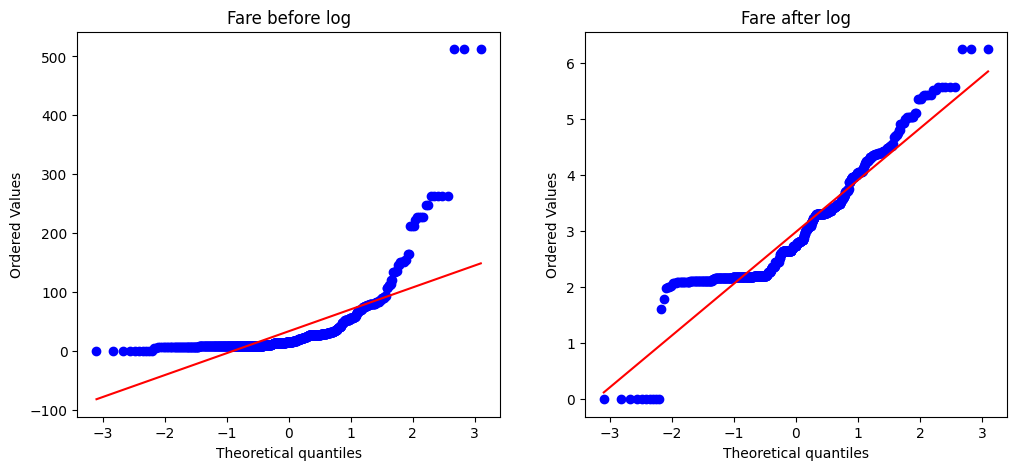

In [ ]:
plt.figure(figsize= (12,5))

plt.subplot(121)
stats.probplot(X_train['Fare'],dist = 'norm',plot = plt)
plt.title('Fare before log')

plt.subplot(122)
stats.probplot(X_train_trans['Fare'],dist = 'norm',plot=plt)
plt.title('Fare after log')
plt.show()

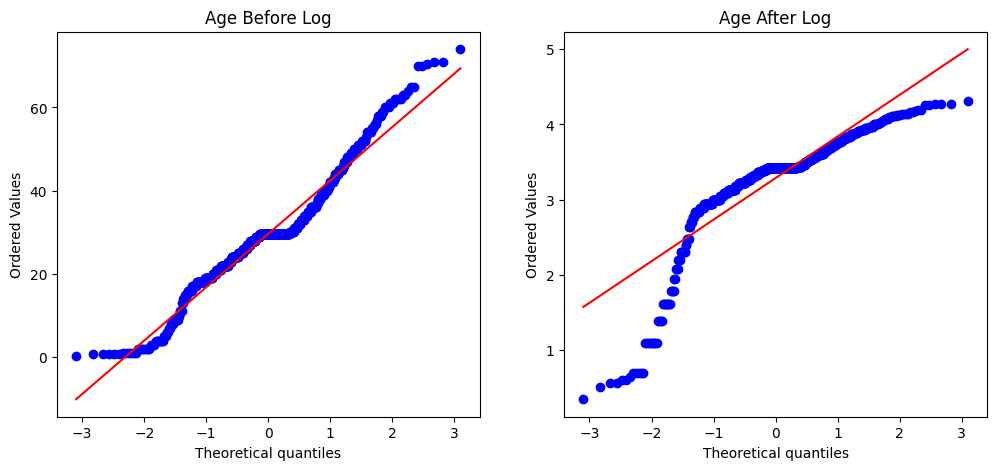

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_trans['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

age data got fucked up .

now only transforming the fare column not age one

In [ ]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder = 'passthrough')

X_train_trans2 = trf2.fit_transform(X_train)
X_test_trans2 = trf2.transform(X_test)

In [ ]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_trans2,y_train)
clf2.fit(X_train_trans2,y_train)

y_pred = clf.predict(X_test_trans2)
y_pred2 = clf2.predict(X_test_trans2)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.7430167597765364
Accuracy DT 0.6759776536312849


In [ ]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6577153558052433


In [ ]:
def apply_trans(transform):
  X = df.iloc[:,1:3]
  y = df.iloc[:,0]

  trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder = 'passthrough')
  X_trans = trf.fit_transform(X)
  clf = LogisticRegression()
  print("Accuracy ",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv = 10)))

  plt.figure(figsize=(12,5))
  plt.subplot(121)
  stats.probplot(X['Fare'],dist = 'norm',plot = plt)
  plt.title('Fare before Transform')

  plt.subplot(122)
  stats.probplot(X_trans[:,0],dist='norm',plot = plt)
  plt.title("Fare after transform")
  plt.show()

Accuracy  0.6195131086142323


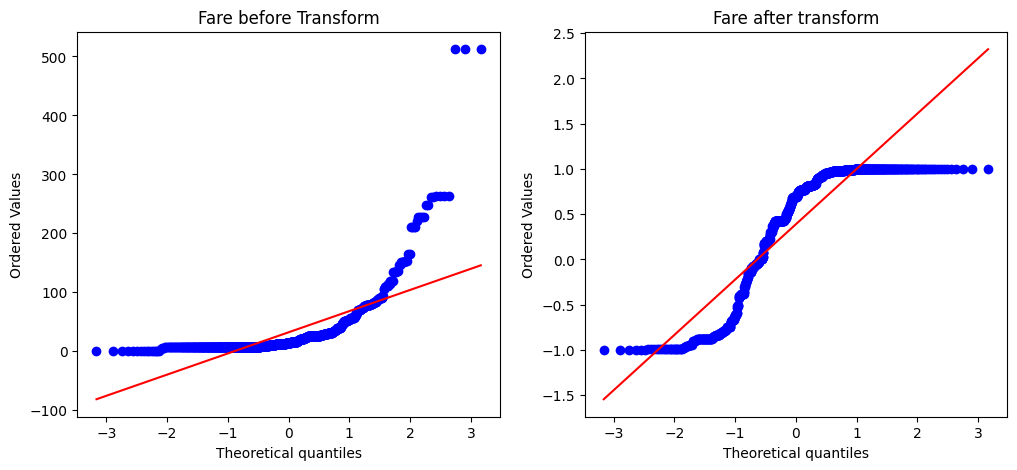

In [ ]:
apply_trans(lambda x:np.sin(x))